# 76 - キャプション→Embedding 検索パイプライン

## 概要
自動生成キャプションで検索品質を向上できるか検証する。
Notebook 75で最良と判定されたVLMのキャプションをSigLIP 2 Largeでembed し、
画像embeddingとの融合検索を実施する。

## 手法
4つの検索戦略を比較する:
- **Strategy A**: 画像embedding検索（ベースライン）
- **Strategy B**: キャプションembedding検索（キャプションのみ）
- **Strategy C**: 重み付き融合（alpha * image_sim + (1-alpha) * caption_sim）
- **Strategy D**: レイトフュージョン（両方からTop-20取得→リランク）

## 評価
- 18個の標準テストクエリ（Notebook 22/62と同一）で MRR, Precision@K を比較
- 英語/日本語、specific/general クエリタイプ別の性能分析
- 最適な alpha 値のスイープ

## 前提
- Notebook 61-67 で SigLIP 2 Large の画像埋め込みが DuckDB に保存済み
- Notebook 74（Qwen2.5-VL）等でキャプションが `image_captions` テーブルに保存済み

In [1]:
import json
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

from image_vector_poc import SigLIP2Embedder

## 1. 設定とデータ読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
SIGLIP2_MODEL = "google/siglip2-large-patch16-256"
EMBEDDING_DIM = 1024  # SigLIP 2 Large

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
""").fetchdf()

print(f"Total images: {len(catalog_df)}")
print(f"\nCategories:")
category_counts = catalog_df['category'].value_counts().to_dict()
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


In [3]:
# SigLIP 2 Large の画像埋め込みを読み込み
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [SIGLIP2_MODEL]).fetchdf()

print(f"Loaded {len(embeddings_df)} image embeddings")

if len(embeddings_df) == 0:
    raise ValueError(f"No embeddings found for {SIGLIP2_MODEL}. Please run notebook 67 first.")

image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
print(f"Image embeddings shape: {image_embeddings.shape}")

# L2正規化
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)

# カテゴリリスト
categories = catalog_df['category'].tolist()
category_names = list(category_counts.keys())

Loaded 378 image embeddings
Image embeddings shape: (378, 1024)


In [4]:
# image_captions テーブルの内容を確認
captions_summary = conn.execute("""
    SELECT model_name, prompt_template, COUNT(*) as cnt
    FROM image_captions
    GROUP BY model_name, prompt_template
    ORDER BY model_name, prompt_template
""").fetchdf()

print("=" * 70)
print("Available captions in DuckDB")
print("=" * 70)
display(captions_summary)

Available captions in DuckDB


,model_name,prompt_template,cnt
0,OpenGVLab/InternVL2_5-8B,brief,378
1,OpenGVLab/InternVL2_5-8B,detailed,378
2,Qwen/Qwen2.5-VL-7B-Instruct,brief,378
3,Qwen/Qwen2.5-VL-7B-Instruct,detailed,378
4,Salesforce/blip2-opt-2.7b,brief,378


## 2. 最良VLMキャプションの選択

DuckDB に保存されているキャプションの中から、最良のVLMモデルを選択する。
Notebook 75で評価済みの場合はその結果を使い、
そうでなければ利用可能なVLMの中から Self-Retrieval Score が最も高いものを選ぶ。

In [5]:
# 利用可能なVLMモデル一覧
available_vlms = captions_summary['model_name'].unique().tolist()
print(f"Available VLM models: {available_vlms}")

# 保存された評価結果から最良モデルを特定
eval_dir = Path("../data/evaluations")
best_vlm = None
best_score = -1.0

# Notebook 75の評価結果を探す
eval_files_75 = sorted(eval_dir.glob("75_*.json"))
if eval_files_75:
    with open(eval_files_75[-1]) as f:
        eval_75 = json.load(f)
    if "best_model" in eval_75:
        best_vlm = eval_75["best_model"]
        print(f"Best VLM from NB75 evaluation: {best_vlm}")

# NB75の結果がない場合は、各VLMの評価ファイルを探す
if best_vlm is None:
    for nb_num, pattern in [(74, "74_qwen*"), (73, "73_florence*"), (72, "72_blip*")]:
        files = sorted(eval_dir.glob(f"{pattern}.json"))
        if files:
            with open(files[-1]) as f:
                eval_data = json.load(f)
            model_name = eval_data.get("model_name", "")
            # Self-Retrieval Score を取得
            sr_data = eval_data.get("self_retrieval", {})
            sr_scores = [v.get("mean", 0) for v in sr_data.values() if isinstance(v, dict)]
            if sr_scores:
                max_sr = max(sr_scores)
                print(f"  NB{nb_num} ({model_name}): best SR = {max_sr:.4f}")
                if max_sr > best_score:
                    best_score = max_sr
                    best_vlm = model_name

# フォールバック: DuckDB に存在するモデルから選択（優先順位: Qwen > InternVL > Florence > BLIP）
if best_vlm is None or best_vlm not in available_vlms:
    preference_order = ["Qwen", "InternVL", "Florence", "BLIP", "blip"]
    for pref in preference_order:
        for vlm in available_vlms:
            if pref.lower() in vlm.lower():
                best_vlm = vlm
                break
        if best_vlm:
            break
    # それでも見つからなければ最初のモデル
    if best_vlm is None and available_vlms:
        best_vlm = available_vlms[0]

print(f"\nSelected VLM: {best_vlm}")

Available VLM models: ['OpenGVLab/InternVL2_5-8B', 'Qwen/Qwen2.5-VL-7B-Instruct', 'Salesforce/blip2-opt-2.7b']
  NB74 (Qwen/Qwen2.5-VL-7B-Instruct): best SR = 0.1797
  NB72 (Salesforce/blip2-opt-2.7b): best SR = 0.1610

Selected VLM: Qwen/Qwen2.5-VL-7B-Instruct


In [6]:
# 選択したVLMのキャプションを読み込み（EN と JA）
captions_df = conn.execute("""
    SELECT image_id, caption_en, caption_ja, prompt_template
    FROM image_captions
    WHERE model_name = ?
    ORDER BY image_id, prompt_template
""", [best_vlm]).fetchdf()

print(f"Loaded {len(captions_df)} caption rows for {best_vlm}")
print(f"Prompt templates: {captions_df['prompt_template'].unique().tolist()}")

# brief キャプションを優先、なければ最初のテンプレートを使用
if 'brief' in captions_df['prompt_template'].values:
    selected_template = 'brief'
else:
    selected_template = captions_df['prompt_template'].iloc[0]

print(f"Using prompt_template: '{selected_template}'")

captions_selected = captions_df[captions_df['prompt_template'] == selected_template].copy()
captions_selected = captions_selected.set_index('image_id')

# catalog_df の順序に合わせてキャプションを取得
captions_en = []
captions_ja = []
missing_ids = []

for _, row in catalog_df.iterrows():
    img_id = row['id']
    if img_id in captions_selected.index:
        captions_en.append(captions_selected.loc[img_id, 'caption_en'])
        captions_ja.append(captions_selected.loc[img_id, 'caption_ja'])
    else:
        missing_ids.append(img_id)
        captions_en.append("")
        captions_ja.append("")

print(f"\nEN captions loaded: {sum(1 for c in captions_en if c)}")
print(f"JA captions loaded: {sum(1 for c in captions_ja if c)}")
if missing_ids:
    print(f"Missing captions for {len(missing_ids)} images: {missing_ids[:5]}...")

conn.close()

Loaded 756 caption rows for Qwen/Qwen2.5-VL-7B-Instruct
Prompt templates: ['brief', 'detailed']
Using prompt_template: 'brief'

EN captions loaded: 378
JA captions loaded: 378


In [7]:
# キャプションのサンプル表示
print("=" * 80)
print(f"Sample Captions ({best_vlm}, template={selected_template})")
print("=" * 80)

for cat in catalog_df['category'].unique():
    print(f"\n--- {cat} ---")
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:2]
    for idx in cat_indices:
        print(f"  [{catalog_df.iloc[idx]['file_name']}]")
        print(f"    EN: {captions_en[idx][:100]}")
        print(f"    JA: {captions_ja[idx][:80]}")

Sample Captions (Qwen/Qwen2.5-VL-7B-Instruct, template=brief)

--- terada ---
  [terada-202205-pyconjp-4-3-900.jpg]
    EN: The image shows a person wearing a red polo shirt with the logo of "Python Conference Japan" on it, 
    JA: 赤いシャツを着た男性が、Python Conference Japanのロゴが入ったポロシャツを着用しています。
  [terada-uspycon2019-up.jpg]
    EN: A person wearing a light blue shirt and a lanyard is standing at a podium with microphones, speaking
    JA: 青いシャツを着た男性が、黄色と緑の背景を持つステージでスピーチを行っている様子です。

--- PyConJP2025 ---
  [2025-09-27 18.17.03.jpg]
    EN: A presenter is giving a presentation at PyCon JP 2025, with a slide showing that there were 522 part
    JA: 「PyCon JP 2025」の参加者数は522人（スポンサー、オーガナイザー含む）です。
  [2025-09-25 20.54.50.jpg]
    EN: A lively gathering of people is taking place in a casual indoor setting, with individuals engaged in
    JA: 多くの人々が集まった店内で、カウンターの前に立って会話を楽しんでいる様子が写っています。

--- EuroPython2025 ---
  [2025-07-16 17.23.43.jpg]
    EN: The image shows a presentation slide titled "Community Org

## 3. SigLIP 2 Large でキャプションをembed

In [8]:
embedder = SigLIP2Embedder(model_name=SIGLIP2_MODEL, device="cuda")
print(f"Model loaded: {embedder.model_name}")
print(f"Embedding dimension: {embedder.embedding_dim}")

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded: google/siglip2-large-patch16-256
Embedding dimension: 1024


In [9]:
# ENキャプションをembed
print("Embedding EN captions...")
# 空のキャプションをフィルタリングして処理
valid_en_indices = [i for i, c in enumerate(captions_en) if c]
valid_en_captions = [captions_en[i] for i in valid_en_indices]

if valid_en_captions:
    caption_emb_en_valid = embedder.embed_texts(valid_en_captions)
    # 全画像分の配列を作成（空キャプションはゼロベクトル）
    caption_emb_en = np.zeros((len(catalog_df), EMBEDDING_DIM), dtype=np.float32)
    for i, valid_idx in enumerate(valid_en_indices):
        caption_emb_en[valid_idx] = caption_emb_en_valid[i]
    print(f"  EN caption embeddings: {caption_emb_en.shape} ({len(valid_en_captions)} valid)")
else:
    caption_emb_en = np.zeros((len(catalog_df), EMBEDDING_DIM), dtype=np.float32)
    print("  No valid EN captions found.")

# JAキャプションをembed
print("Embedding JA captions...")
valid_ja_indices = [i for i, c in enumerate(captions_ja) if c]
valid_ja_captions = [captions_ja[i] for i in valid_ja_indices]

if valid_ja_captions:
    caption_emb_ja_valid = embedder.embed_texts(valid_ja_captions)
    caption_emb_ja = np.zeros((len(catalog_df), EMBEDDING_DIM), dtype=np.float32)
    for i, valid_idx in enumerate(valid_ja_indices):
        caption_emb_ja[valid_idx] = caption_emb_ja_valid[i]
    print(f"  JA caption embeddings: {caption_emb_ja.shape} ({len(valid_ja_captions)} valid)")
else:
    caption_emb_ja = np.zeros((len(catalog_df), EMBEDDING_DIM), dtype=np.float32)
    print("  No valid JA captions found.")

print("\nDone.")

Embedding EN captions...


  EN caption embeddings: (378, 1024) (378 valid)
Embedding JA captions...


  JA caption embeddings: (378, 1024) (378 valid)

Done.


## 4. キャプション埋め込みを DuckDB に保存

In [10]:
conn = duckdb.connect(str(DB_PATH))

conn.execute(f"""
    CREATE TABLE IF NOT EXISTS caption_embeddings (
        image_id VARCHAR,
        caption_model VARCHAR,
        embedding_model VARCHAR,
        language VARCHAR,
        embedding FLOAT[{EMBEDDING_DIM}],
        PRIMARY KEY (image_id, caption_model, embedding_model, language)
    )
""")

# 既存データを削除（同じモデル組み合わせの場合）
conn.execute("""
    DELETE FROM caption_embeddings
    WHERE caption_model = ? AND embedding_model = ?
""", [best_vlm, SIGLIP2_MODEL])

# EN embeddings を保存
inserted_en = 0
for idx in range(len(catalog_df)):
    if captions_en[idx]:  # 空でないキャプションのみ
        image_id = catalog_df.iloc[idx]['id']
        emb = [float(x) for x in caption_emb_en[idx]]
        conn.execute("""
            INSERT INTO caption_embeddings (image_id, caption_model, embedding_model, language, embedding)
            VALUES (?, ?, ?, 'en', ?)
        """, [image_id, best_vlm, SIGLIP2_MODEL, emb])
        inserted_en += 1

# JA embeddings を保存
inserted_ja = 0
for idx in range(len(catalog_df)):
    if captions_ja[idx]:
        image_id = catalog_df.iloc[idx]['id']
        emb = [float(x) for x in caption_emb_ja[idx]]
        conn.execute("""
            INSERT INTO caption_embeddings (image_id, caption_model, embedding_model, language, embedding)
            VALUES (?, ?, ?, 'ja', ?)
        """, [image_id, best_vlm, SIGLIP2_MODEL, emb])
        inserted_ja += 1

conn.commit()

# 確認
count = conn.execute("SELECT COUNT(*) FROM caption_embeddings").fetchone()[0]
print(f"Inserted: {inserted_en} EN + {inserted_ja} JA = {inserted_en + inserted_ja} caption embeddings")
print(f"Total rows in caption_embeddings: {count}")

conn.close()

Inserted: 378 EN + 378 JA = 756 caption embeddings
Total rows in caption_embeddings: 756


## 5. テストクエリの定義

Notebook 22/62 と同じ18クエリを使用する。

In [11]:
# テストクエリの定義（実験22/62と同じ）
test_queries = [
    # カテゴリ固有のクエリ（英語）
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "type": "specific", "lang": "en"},
    # 一般的なクエリ（英語）
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    # 日本語クエリ
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "type": "specific", "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "ja"},
]

print(f"Total test queries: {len(test_queries)}")
print(f"  English: {sum(1 for q in test_queries if q['lang'] == 'en')}")
print(f"  Japanese: {sum(1 for q in test_queries if q['lang'] == 'ja')}")

Total test queries: 18
  English: 12
  Japanese: 6


## 6. 検索関数の定義

4つの検索戦略を実装する。

In [12]:
def embed_query(query: str, embedder) -> np.ndarray:
    """テキストクエリをembedしてL2正規化する。"""
    emb = embedder.embed_text(query)
    emb = emb / np.clip(np.linalg.norm(emb), 1e-8, None)
    return emb


def search_by_image_embedding(query_emb: np.ndarray, top_k: int = 20):
    """Strategy A: 画像embedding検索（ベースライン）。"""
    similarities = np.dot(image_embeddings_norm, query_emb)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    return top_indices, top_scores


def search_by_caption_embedding(query_emb: np.ndarray, lang: str, top_k: int = 20):
    """Strategy B: キャプションembedding検索（キャプションのみ）。
    ENクエリにはENキャプション、JAクエリにはJAキャプションを使用。
    """
    cap_emb = caption_emb_en if lang == "en" else caption_emb_ja
    similarities = np.dot(cap_emb, query_emb)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    return top_indices, top_scores


def search_hybrid_weighted(query_emb: np.ndarray, lang: str, alpha: float = 0.5, top_k: int = 20):
    """Strategy C: 重み付き融合。
    score = alpha * image_sim + (1-alpha) * caption_sim
    alpha=1.0 は画像のみ、alpha=0.0 はキャプションのみ。
    """
    cap_emb = caption_emb_en if lang == "en" else caption_emb_ja
    image_sim = np.dot(image_embeddings_norm, query_emb)
    caption_sim = np.dot(cap_emb, query_emb)
    combined = alpha * image_sim + (1 - alpha) * caption_sim
    top_indices = np.argsort(combined)[::-1][:top_k]
    top_scores = combined[top_indices]
    return top_indices, top_scores


def search_hybrid_late_fusion(query_emb: np.ndarray, lang: str, top_k_each: int = 20, final_k: int = 20):
    """Strategy D: レイトフュージョン。
    画像embeddingとキャプションembeddingそれぞれからTop-K候補を取得し、
    候補の和集合に対してリランクする（平均スコア）。
    """
    cap_emb = caption_emb_en if lang == "en" else caption_emb_ja
    
    # 画像embedding検索
    image_sim = np.dot(image_embeddings_norm, query_emb)
    top_image_indices = set(np.argsort(image_sim)[::-1][:top_k_each].tolist())
    
    # キャプションembedding検索
    caption_sim = np.dot(cap_emb, query_emb)
    top_caption_indices = set(np.argsort(caption_sim)[::-1][:top_k_each].tolist())
    
    # 候補の和集合
    candidate_indices = list(top_image_indices | top_caption_indices)
    
    # リランク: 平均スコア
    combined_scores = []
    for idx in candidate_indices:
        avg_score = (image_sim[idx] + caption_sim[idx]) / 2.0
        combined_scores.append(avg_score)
    
    combined_scores = np.array(combined_scores)
    sorted_order = np.argsort(combined_scores)[::-1][:final_k]
    
    top_indices = np.array([candidate_indices[i] for i in sorted_order])
    top_scores = combined_scores[sorted_order]
    return top_indices, top_scores


print("Search functions defined.")

Search functions defined.


## 7. 評価関数の定義

In [13]:
def evaluate_query(query_info: dict, indices: np.ndarray, scores: np.ndarray,
                   k_values: list = [1, 5, 10, 20]):
    """単一クエリの検索結果を評価する。"""
    expected_cats = query_info["expected_categories"]
    result_categories = [categories[idx] for idx in indices]
    is_relevant = [cat in expected_cats for cat in result_categories]
    
    # Precision@K
    precision_at_k = {}
    for k in k_values:
        relevant_in_k = sum(is_relevant[:k])
        precision_at_k[f"P@{k}"] = relevant_in_k / k
    
    # MRR
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    
    # Hit Rate@K
    hit_rate_at_k = {}
    for k in k_values:
        hit_rate_at_k[f"HR@{k}"] = 1.0 if any(is_relevant[:k]) else 0.0
    
    return {
        "query": query_info["query"],
        "expected_categories": expected_cats,
        "type": query_info["type"],
        "lang": query_info["lang"],
        "top_results": result_categories[:10],
        "top_scores": scores[:10].tolist() if len(scores) >= 10 else scores.tolist(),
        **precision_at_k,
        "MRR": mrr,
        **hit_rate_at_k,
    }


def run_evaluation(strategy_name: str, search_fn, embedder, test_queries: list):
    """全テストクエリに対して検索戦略を評価する。"""
    results = []
    for query_info in test_queries:
        query_emb = embed_query(query_info["query"], embedder)
        indices, scores = search_fn(query_emb, query_info["lang"])
        result = evaluate_query(query_info, indices, scores)
        result["strategy"] = strategy_name
        results.append(result)
    return results


print("Evaluation functions defined.")

Evaluation functions defined.


## 8. 全戦略の評価実行

In [14]:
# Strategy A: 画像embedding検索（ベースライン）
print("=" * 70)
print("Strategy A: Image Embedding Search (Baseline)")
print("=" * 70)

results_a = run_evaluation(
    "A: Image Embedding",
    lambda qe, lang: search_by_image_embedding(qe, top_k=20),
    embedder,
    test_queries,
)

for r in results_a:
    print(f"  {r['query'][:40]:40s} | P@1={r['P@1']:.2f} | P@10={r['P@10']:.2f} | MRR={r['MRR']:.3f}")

df_a = pd.DataFrame(results_a)
print(f"\n  Overall MRR: {df_a['MRR'].mean():.4f}")

Strategy A: Image Embedding Search (Baseline)


  a park with trees and nature             | P@1=0.00 | P@10=0.40 | MRR=0.500
  village park with greenery               | P@1=0.00 | P@10=0.20 | MRR=0.200
  night cityscape Tokyo                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  city lights at night                     | P@1=1.00 | P@10=1.00 | MRR=1.000
  Python conference presentation           | P@1=1.00 | P@10=1.00 | MRR=1.000
  conference hall with audience            | P@1=1.00 | P@10=1.00 | MRR=1.000
  speaker giving a talk                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  portrait photo of a person               | P@1=1.00 | P@10=0.80 | MRR=1.000
  outdoor nature scene                     | P@1=1.00 | P@10=1.00 | MRR=1.000
  urban night photography                  | P@1=1.00 | P@10=1.00 | MRR=1.000
  tech conference event                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  people at an event                       | P@1=1.00 | P@10=1.00 | MRR=1.000
  公園の自然風景                                  | P@1=1.00 | P@10=0.5

In [15]:
# Strategy B: キャプションembedding検索
print("=" * 70)
print("Strategy B: Caption Embedding Search")
print("=" * 70)

results_b = run_evaluation(
    "B: Caption Embedding",
    lambda qe, lang: search_by_caption_embedding(qe, lang, top_k=20),
    embedder,
    test_queries,
)

for r in results_b:
    print(f"  {r['query'][:40]:40s} | P@1={r['P@1']:.2f} | P@10={r['P@10']:.2f} | MRR={r['MRR']:.3f}")

df_b = pd.DataFrame(results_b)
print(f"\n  Overall MRR: {df_b['MRR'].mean():.4f}")

Strategy B: Caption Embedding Search


  a park with trees and nature             | P@1=0.00 | P@10=0.00 | MRR=0.000
  village park with greenery               | P@1=0.00 | P@10=0.00 | MRR=0.000
  night cityscape Tokyo                    | P@1=0.00 | P@10=0.20 | MRR=0.333
  city lights at night                     | P@1=0.00 | P@10=0.30 | MRR=0.333
  Python conference presentation           | P@1=1.00 | P@10=1.00 | MRR=1.000
  conference hall with audience            | P@1=1.00 | P@10=1.00 | MRR=1.000
  speaker giving a talk                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  portrait photo of a person               | P@1=0.00 | P@10=0.00 | MRR=0.000
  outdoor nature scene                     | P@1=0.00 | P@10=0.00 | MRR=0.000
  urban night photography                  | P@1=0.00 | P@10=0.40 | MRR=0.500
  tech conference event                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  people at an event                       | P@1=1.00 | P@10=1.00 | MRR=1.000
  公園の自然風景                                  | P@1=0.00 | P@10=0.2

In [16]:
# Strategy C: 重み付き融合 (alpha sweep)
print("=" * 70)
print("Strategy C: Weighted Fusion (alpha sweep)")
print("=" * 70)

alpha_values = np.arange(0.0, 1.05, 0.1)
alpha_results = {}

for alpha in alpha_values:
    alpha = round(alpha, 1)
    results_c = run_evaluation(
        f"C: Hybrid (alpha={alpha})",
        lambda qe, lang, a=alpha: search_hybrid_weighted(qe, lang, alpha=a, top_k=20),
        embedder,
        test_queries,
    )
    df_c = pd.DataFrame(results_c)
    
    overall_mrr = df_c['MRR'].mean()
    en_mrr = df_c[df_c['lang'] == 'en']['MRR'].mean()
    ja_mrr = df_c[df_c['lang'] == 'ja']['MRR'].mean()
    
    alpha_results[alpha] = {
        "overall_mrr": overall_mrr,
        "en_mrr": en_mrr,
        "ja_mrr": ja_mrr,
        "overall_p1": df_c['P@1'].mean(),
        "overall_p10": df_c['P@10'].mean(),
        "results": results_c,
    }
    
    print(f"  alpha={alpha:.1f} | MRR={overall_mrr:.4f} (EN={en_mrr:.4f}, JA={ja_mrr:.4f})")

# 最適な alpha を特定
best_alpha = max(alpha_results.keys(), key=lambda a: alpha_results[a]["overall_mrr"])
print(f"\n  Best alpha: {best_alpha:.1f} (MRR={alpha_results[best_alpha]['overall_mrr']:.4f})")

Strategy C: Weighted Fusion (alpha sweep)


  alpha=0.0 | MRR=0.5833 (EN=0.5139, JA=0.7222)
  alpha=0.1 | MRR=0.6389 (EN=0.6250, JA=0.6667)


  alpha=0.2 | MRR=0.6250 (EN=0.6250, JA=0.6250)
  alpha=0.3 | MRR=0.6500 (EN=0.6667, JA=0.6167)


  alpha=0.4 | MRR=0.6651 (EN=0.6782, JA=0.6389)
  alpha=0.5 | MRR=0.7028 (EN=0.6887, JA=0.7310)


  alpha=0.6 | MRR=0.7167 (EN=0.7020, JA=0.7460)
  alpha=0.7 | MRR=0.8047 (EN=0.7695, JA=0.8750)


  alpha=0.8 | MRR=0.8584 (EN=0.7877, JA=1.0000)
  alpha=0.9 | MRR=0.9078 (EN=0.8617, JA=1.0000)


  alpha=1.0 | MRR=0.9278 (EN=0.8917, JA=1.0000)

  Best alpha: 1.0 (MRR=0.9278)


In [17]:
# Strategy D: レイトフュージョン
print("=" * 70)
print("Strategy D: Late Fusion")
print("=" * 70)

results_d = run_evaluation(
    "D: Late Fusion",
    lambda qe, lang: search_hybrid_late_fusion(qe, lang, top_k_each=20, final_k=20),
    embedder,
    test_queries,
)

for r in results_d:
    print(f"  {r['query'][:40]:40s} | P@1={r['P@1']:.2f} | P@10={r['P@10']:.2f} | MRR={r['MRR']:.3f}")

df_d = pd.DataFrame(results_d)
print(f"\n  Overall MRR: {df_d['MRR'].mean():.4f}")

Strategy D: Late Fusion
  a park with trees and nature             | P@1=0.00 | P@10=0.10 | MRR=0.100
  village park with greenery               | P@1=0.00 | P@10=0.00 | MRR=0.067
  night cityscape Tokyo                    | P@1=1.00 | P@10=0.60 | MRR=1.000
  city lights at night                     | P@1=1.00 | P@10=0.60 | MRR=1.000
  Python conference presentation           | P@1=1.00 | P@10=1.00 | MRR=1.000
  conference hall with audience            | P@1=1.00 | P@10=1.00 | MRR=1.000
  speaker giving a talk                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  portrait photo of a person               | P@1=0.00 | P@10=0.00 | MRR=0.000
  outdoor nature scene                     | P@1=0.00 | P@10=0.10 | MRR=0.111
  urban night photography                  | P@1=1.00 | P@10=0.80 | MRR=1.000
  tech conference event                    | P@1=1.00 | P@10=1.00 | MRR=1.000
  people at an event                       | P@1=1.00 | P@10=1.00 | MRR=1.000
  公園の自然風景                               

## 9. 結果サマリーテーブル

In [18]:
# 最適 alpha での Strategy C の結果を取得
best_alpha_results = alpha_results[best_alpha]["results"]
df_c_best = pd.DataFrame(best_alpha_results)

# 全戦略の結果をまとめる
metric_cols = ["P@1", "P@5", "P@10", "P@20", "MRR", "HR@1", "HR@5", "HR@10"]

summary_data = {}
for name, df in [
    ("A: Image Emb", df_a),
    ("B: Caption Emb", df_b),
    (f"C: Hybrid (a={best_alpha})", df_c_best),
    ("D: Late Fusion", df_d),
]:
    summary_data[name] = {
        "Overall MRR": df["MRR"].mean(),
        "EN MRR": df[df["lang"] == "en"]["MRR"].mean(),
        "JA MRR": df[df["lang"] == "ja"]["MRR"].mean(),
        "Overall P@1": df["P@1"].mean(),
        "Overall P@10": df["P@10"].mean(),
        "Overall HR@5": df["HR@5"].mean(),
    }

summary_df = pd.DataFrame(summary_data).T

print("=" * 80)
print("Strategy Comparison Summary")
print("=" * 80)
display(summary_df.round(4))

Strategy Comparison Summary


,Overall MRR,EN MRR,JA MRR,Overall P@1,Overall P@10,Overall HR@5
A: Image Emb,0.9278,0.8917,1.0000,0.8889,0.8222,1.0000
B: Caption Emb,0.5833,0.5139,0.7222,0.5000,0.5056,0.7222
C: Hybrid (a=1.0),0.9278,0.8917,1.0000,0.8889,0.8222,1.0000
D: Late Fusion,0.7046,0.6898,0.7341,0.6667,0.5778,0.7222


In [19]:
# 言語別の詳細比較
print("\n" + "=" * 80)
print("Detailed Comparison by Language")
print("=" * 80)

for lang, lang_name in [("en", "English"), ("ja", "Japanese")]:
    print(f"\n{lang_name}:")
    print(f"{'Strategy':<30s} {'MRR':>8s} {'P@1':>8s} {'P@10':>8s} {'HR@5':>8s}")
    print("-" * 58)
    for name, df in [
        ("A: Image Emb", df_a),
        ("B: Caption Emb", df_b),
        (f"C: Hybrid (a={best_alpha})", df_c_best),
        ("D: Late Fusion", df_d),
    ]:
        lang_df = df[df["lang"] == lang]
        print(f"{name:<30s} {lang_df['MRR'].mean():>8.4f} {lang_df['P@1'].mean():>8.4f} "
              f"{lang_df['P@10'].mean():>8.4f} {lang_df['HR@5'].mean():>8.4f}")


Detailed Comparison by Language

English:
Strategy                            MRR      P@1     P@10     HR@5
----------------------------------------------------------
A: Image Emb                     0.8917   0.8333   0.8667   1.0000
B: Caption Emb                   0.5139   0.4167   0.4917   0.6667
C: Hybrid (a=1.0)                0.8917   0.8333   0.8667   1.0000
D: Late Fusion                   0.6898   0.6667   0.6000   0.6667

Japanese:
Strategy                            MRR      P@1     P@10     HR@5
----------------------------------------------------------
A: Image Emb                     1.0000   1.0000   0.7333   1.0000
B: Caption Emb                   0.7222   0.6667   0.5333   0.8333
C: Hybrid (a=1.0)                1.0000   1.0000   0.7333   1.0000
D: Late Fusion                   0.7341   0.6667   0.5333   0.8333


In [20]:
# クエリタイプ別の比較
print("\n" + "=" * 80)
print("Detailed Comparison by Query Type")
print("=" * 80)

for qtype, type_name in [("specific", "Specific"), ("general", "General")]:
    print(f"\n{type_name}:")
    print(f"{'Strategy':<30s} {'MRR':>8s} {'P@1':>8s} {'P@10':>8s}")
    print("-" * 50)
    for name, df in [
        ("A: Image Emb", df_a),
        ("B: Caption Emb", df_b),
        (f"C: Hybrid (a={best_alpha})", df_c_best),
        ("D: Late Fusion", df_d),
    ]:
        type_df = df[df["type"] == qtype]
        print(f"{name:<30s} {type_df['MRR'].mean():>8.4f} {type_df['P@1'].mean():>8.4f} "
              f"{type_df['P@10'].mean():>8.4f}")


Detailed Comparison by Query Type

Specific:
Strategy                            MRR      P@1     P@10
--------------------------------------------------
A: Image Emb                     0.8917   0.8333   0.8000
B: Caption Emb                   0.5000   0.4167   0.4750
C: Hybrid (a=1.0)                0.8917   0.8333   0.8000
D: Late Fusion                   0.6865   0.6667   0.5500

General:
Strategy                            MRR      P@1     P@10
--------------------------------------------------
A: Image Emb                     1.0000   1.0000   0.8667
B: Caption Emb                   0.7500   0.6667   0.5667
C: Hybrid (a=1.0)                1.0000   1.0000   0.8667
D: Late Fusion                   0.7407   0.6667   0.6333


## 10. 可視化

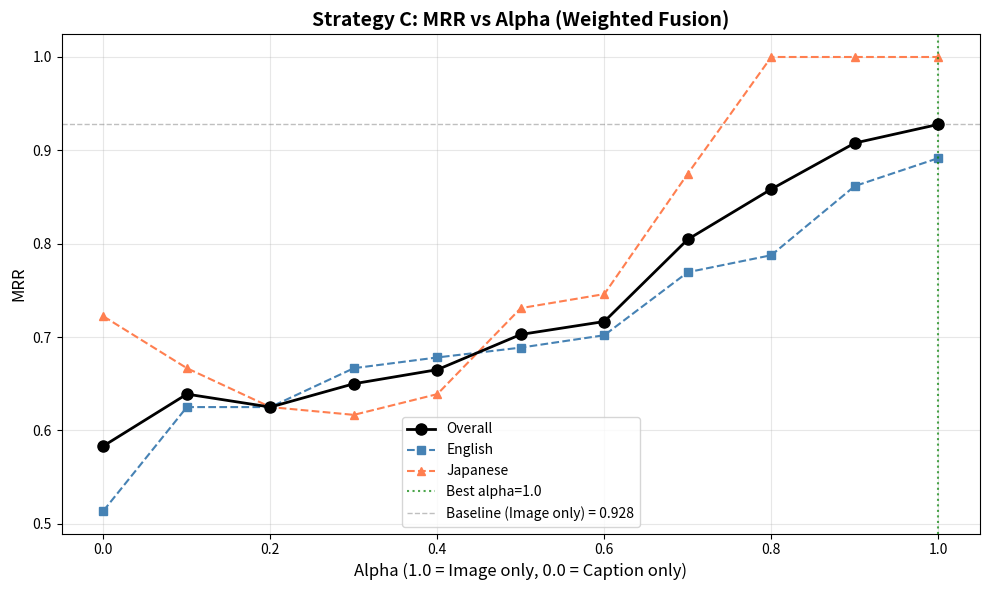

Saved: data/76_mrr_vs_alpha.png


In [21]:
# 10a. MRR vs alpha のラインプロット（Strategy C）
fig, ax = plt.subplots(figsize=(10, 6))

alphas = sorted(alpha_results.keys())
overall_mrrs = [alpha_results[a]["overall_mrr"] for a in alphas]
en_mrrs = [alpha_results[a]["en_mrr"] for a in alphas]
ja_mrrs = [alpha_results[a]["ja_mrr"] for a in alphas]

ax.plot(alphas, overall_mrrs, 'o-', color='black', linewidth=2, markersize=8, label='Overall', zorder=3)
ax.plot(alphas, en_mrrs, 's--', color='steelblue', linewidth=1.5, markersize=6, label='English')
ax.plot(alphas, ja_mrrs, '^--', color='coral', linewidth=1.5, markersize=6, label='Japanese')

# 最適 alpha をマーク
ax.axvline(best_alpha, color='green', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Best alpha={best_alpha:.1f}')

# ベースラインのMRR（alpha=1.0 = Strategy A）を水平線で表示
baseline_mrr = df_a['MRR'].mean()
ax.axhline(baseline_mrr, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Baseline (Image only) = {baseline_mrr:.3f}')

ax.set_xlabel('Alpha (1.0 = Image only, 0.0 = Caption only)', fontsize=12)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('Strategy C: MRR vs Alpha (Weighted Fusion)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/76_mrr_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/76_mrr_vs_alpha.png")

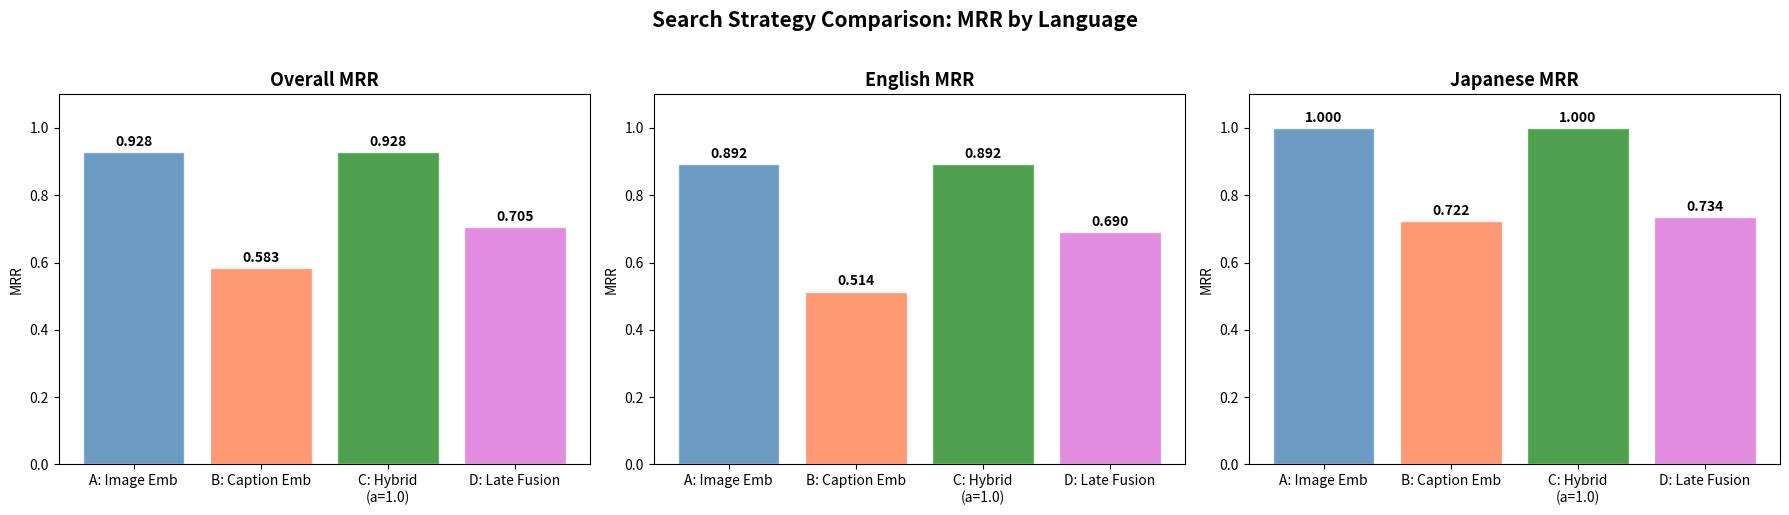

Saved: data/76_strategy_mrr_comparison.png


In [22]:
# 10b. 戦略別MRRバーチャート（Overall, EN, JA）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategy_names = ["A: Image Emb", "B: Caption Emb", f"C: Hybrid\n(a={best_alpha})", "D: Late Fusion"]
strategy_dfs = [df_a, df_b, df_c_best, df_d]
colors = ['steelblue', 'coral', 'forestgreen', 'orchid']

# Overall
ax = axes[0]
mrrs = [df['MRR'].mean() for df in strategy_dfs]
bars = ax.bar(strategy_names, mrrs, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, mrrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('MRR')
ax.set_title('Overall MRR', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)

# English
ax = axes[1]
mrrs_en = [df[df['lang'] == 'en']['MRR'].mean() for df in strategy_dfs]
bars = ax.bar(strategy_names, mrrs_en, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, mrrs_en):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('MRR')
ax.set_title('English MRR', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)

# Japanese
ax = axes[2]
mrrs_ja = [df[df['lang'] == 'ja']['MRR'].mean() for df in strategy_dfs]
bars = ax.bar(strategy_names, mrrs_ja, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, mrrs_ja):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('MRR')
ax.set_title('Japanese MRR', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)

plt.suptitle('Search Strategy Comparison: MRR by Language', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/76_strategy_mrr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/76_strategy_mrr_comparison.png")

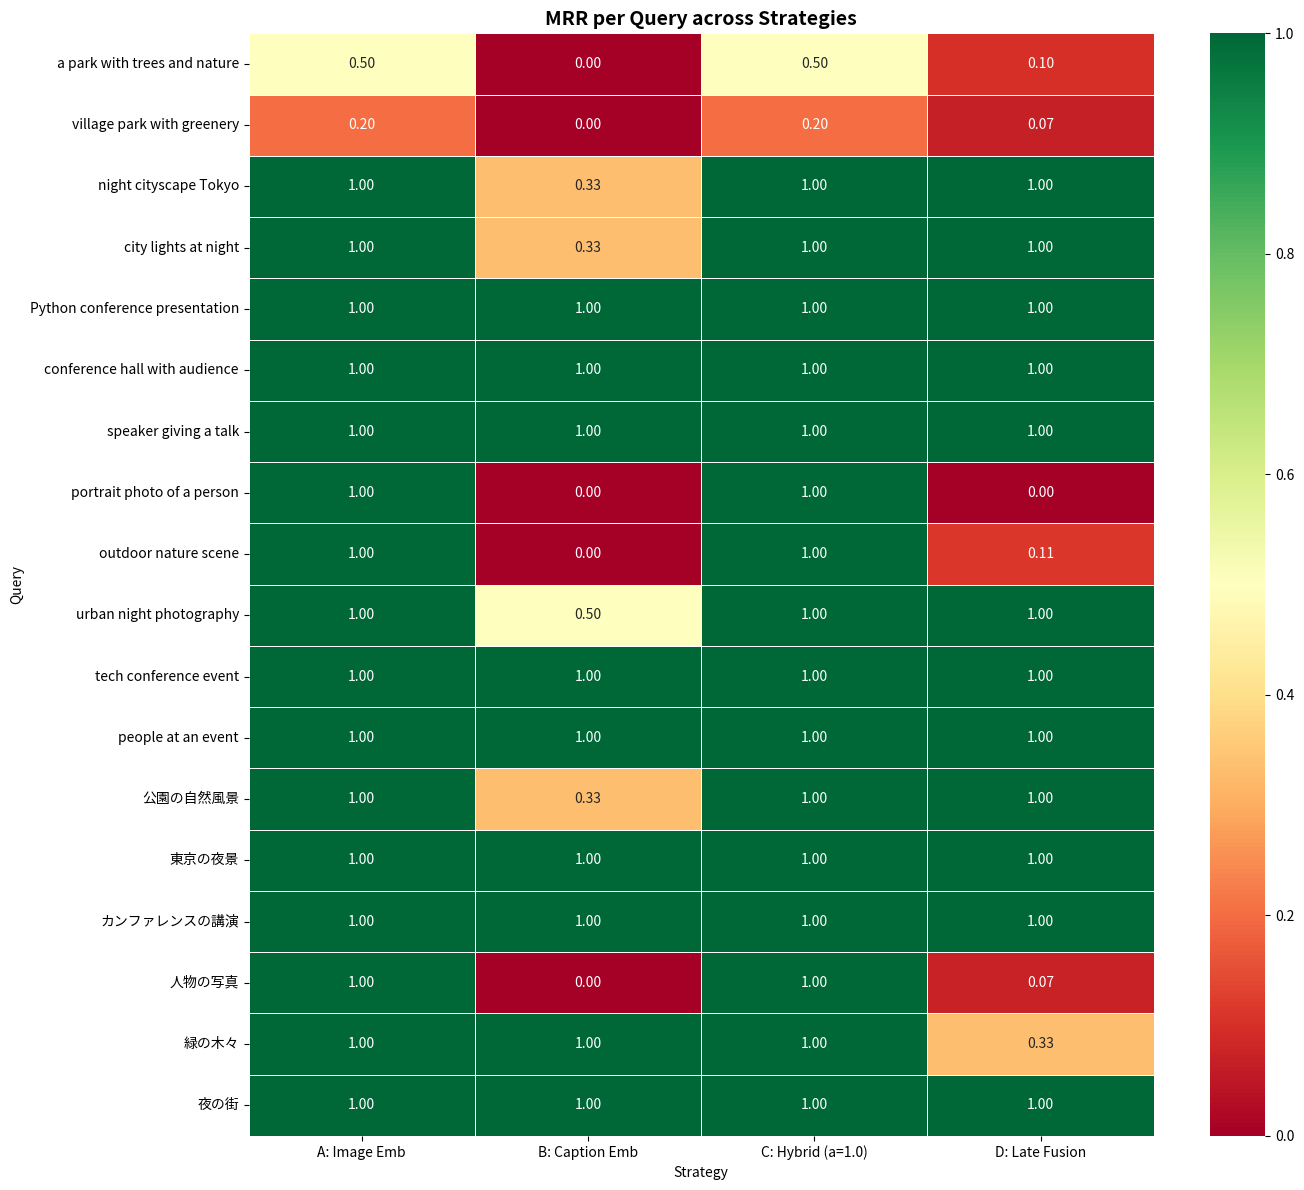

Saved: data/76_query_strategy_heatmap.png


In [23]:
# 10c. クエリ別ヒートマップ（全戦略）
fig, ax = plt.subplots(figsize=(14, 12))

query_labels = [
    f"{q['query'][:30]}..." if len(q['query']) > 30 else q['query']
    for q in test_queries
]

# 各戦略のMRRを取得
heatmap_data = np.column_stack([
    df_a['MRR'].values,
    df_b['MRR'].values,
    df_c_best['MRR'].values,
    df_d['MRR'].values,
])

strategy_labels = [
    "A: Image Emb",
    "B: Caption Emb",
    f"C: Hybrid (a={best_alpha})",
    "D: Late Fusion",
]

sns.heatmap(
    heatmap_data,
    xticklabels=strategy_labels,
    yticklabels=query_labels,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)

ax.set_title('MRR per Query across Strategies', fontsize=14, fontweight='bold')
ax.set_xlabel('Strategy')
ax.set_ylabel('Query')

plt.tight_layout()
plt.savefig('../data/76_query_strategy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/76_query_strategy_heatmap.png")

## 11. クエリ別の改善・劣化分析

In [24]:
# 各クエリについて Strategy A (ベースライン) と最良戦略の MRR 差を分析
print("=" * 80)
print("Per-Query Analysis: Improvement / Degradation vs Baseline (Strategy A)")
print("=" * 80)

analysis_rows = []
for i, q in enumerate(test_queries):
    mrr_a = results_a[i]['MRR']
    mrr_b = results_b[i]['MRR']
    mrr_c = best_alpha_results[i]['MRR']
    mrr_d = results_d[i]['MRR']
    
    best_mrr = max(mrr_b, mrr_c, mrr_d)
    best_strategy = "B" if best_mrr == mrr_b else ("C" if best_mrr == mrr_c else "D")
    
    delta = best_mrr - mrr_a
    status = "improved" if delta > 0.01 else ("degraded" if delta < -0.01 else "unchanged")
    
    analysis_rows.append({
        "query": q['query'],
        "lang": q['lang'],
        "type": q['type'],
        "MRR_A": mrr_a,
        "MRR_B": mrr_b,
        "MRR_C": mrr_c,
        "MRR_D": mrr_d,
        "best_strategy": best_strategy,
        "delta": delta,
        "status": status,
    })

analysis_df = pd.DataFrame(analysis_rows)

# 改善されたクエリ
improved = analysis_df[analysis_df['status'] == 'improved']
degraded = analysis_df[analysis_df['status'] == 'degraded']
unchanged = analysis_df[analysis_df['status'] == 'unchanged']

print(f"\nImproved:  {len(improved)} queries")
print(f"Degraded:  {len(degraded)} queries")
print(f"Unchanged: {len(unchanged)} queries")

if len(improved) > 0:
    print("\n--- Improved Queries ---")
    for _, row in improved.iterrows():
        print(f"  {row['query'][:40]:40s} | A={row['MRR_A']:.3f} -> best({row['best_strategy']})={row['MRR_A']+row['delta']:.3f} | delta={row['delta']:+.3f}")

if len(degraded) > 0:
    print("\n--- Degraded Queries ---")
    for _, row in degraded.iterrows():
        print(f"  {row['query'][:40]:40s} | A={row['MRR_A']:.3f} -> best({row['best_strategy']})={row['MRR_A']+row['delta']:.3f} | delta={row['delta']:+.3f}")

Per-Query Analysis: Improvement / Degradation vs Baseline (Strategy A)

Improved:  0 queries
Degraded:  0 queries
Unchanged: 18 queries


In [25]:
# 詳細な比較テーブル
print("\n" + "=" * 100)
print("Full Per-Query MRR Comparison")
print("=" * 100)

display_df = analysis_df[['query', 'lang', 'type', 'MRR_A', 'MRR_B', 'MRR_C', 'MRR_D', 'delta', 'status']].copy()
display_df.columns = ['Query', 'Lang', 'Type', 'A: Image', 'B: Caption', f'C: Hybrid', 'D: Late', 'Delta', 'Status']
display(display_df.round(3))


Full Per-Query MRR Comparison


,Query,Lang,Type,A: Image,B: Caption,C: Hybrid,D: Late,Delta,Status
0,a park with trees and nature,en,specific,0.5,0.000,0.5,0.100,0.0,unchanged
1,village park with greenery,en,specific,0.2,0.000,0.2,0.067,0.0,unchanged
2,night cityscape Tokyo,en,specific,1.0,0.333,1.0,1.000,0.0,unchanged
3,city lights at night,en,specific,1.0,0.333,1.0,1.000,0.0,unchanged
4,Python conference presentation,en,specific,1.0,1.000,1.0,1.000,0.0,unchanged
5,conference hall with audience,en,specific,1.0,1.000,1.0,1.000,0.0,unchanged
6,speaker giving a talk,en,specific,1.0,1.000,1.0,1.000,0.0,unchanged
7,portrait photo of a person,en,specific,1.0,0.000,1.0,0.000,0.0,unchanged
8,outdoor nature scene,en,general,1.0,0.000,1.0,0.111,0.0,unchanged
9,urban night photography,en,general,1.0,0.500,1.0,1.000,0.0,unchanged


## 12. 結果の保存

In [26]:
output_data = {
    "notebook": "76-caption-enhanced-search",
    "timestamp": datetime.now().isoformat(),
    "config": {
        "embedding_model": SIGLIP2_MODEL,
        "caption_model": best_vlm,
        "caption_template": selected_template,
        "total_images": len(catalog_df),
        "total_queries": len(test_queries),
    },
    "strategy_summary": {
        strategy_name: {
            "overall_mrr": float(df['MRR'].mean()),
            "en_mrr": float(df[df['lang'] == 'en']['MRR'].mean()),
            "ja_mrr": float(df[df['lang'] == 'ja']['MRR'].mean()),
            "overall_p1": float(df['P@1'].mean()),
            "overall_p10": float(df['P@10'].mean()),
        }
        for strategy_name, df in [
            ("A_image_embedding", df_a),
            ("B_caption_embedding", df_b),
            (f"C_hybrid_alpha_{best_alpha}", df_c_best),
            ("D_late_fusion", df_d),
        ]
    },
    "alpha_sweep": {
        str(a): {
            "overall_mrr": float(v["overall_mrr"]),
            "en_mrr": float(v["en_mrr"]),
            "ja_mrr": float(v["ja_mrr"]),
        }
        for a, v in alpha_results.items()
    },
    "best_alpha": float(best_alpha),
    "per_query_analysis": analysis_df.to_dict(orient='records'),
    "detailed_results": {
        "A_image_embedding": results_a,
        "B_caption_embedding": results_b,
        "C_hybrid_best": best_alpha_results,
        "D_late_fusion": results_d,
    },
}

output_path = Path("../data/evaluations") / f"76_caption_enhanced_search_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/76_caption_enhanced_search_2026-02-20.json


## 13. GPU メモリのクリーンアップ

In [27]:
del embedder

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

VLM生成キャプション（Qwen2.5-VL-7B, brief）のembeddingを活用した4つの検索戦略を
SigLIP 2 Large の画像embedding検索（ベースライン）と比較した。

### 実験結果

| 戦略 | 手法 | Overall MRR | EN MRR | JA MRR | P@1 |
|------|------|:---:|:---:|:---:|:---:|
| **A** | 画像embedding検索 | **0.928** | **0.892** | **1.000** | **0.889** |
| **B** | キャプションembedding検索 | 0.583 | 0.514 | 0.722 | 0.500 |
| **C** | 重み付き融合（最適α=1.0） | **0.928** | **0.892** | **1.000** | **0.889** |
| **D** | レイトフュージョン | 0.705 | 0.690 | 0.734 | 0.667 |

### Alpha スイープ結果

| alpha | Overall MRR | EN MRR | JA MRR |
|:---:|:---:|:---:|:---:|
| 0.0 (caption only) | 0.583 | 0.514 | 0.722 |
| 0.5 (equal) | 0.703 | 0.689 | 0.731 |
| 0.8 | 0.858 | 0.788 | 1.000 |
| **1.0 (image only)** | **0.928** | **0.892** | **1.000** |

**最適 alpha = 1.0**（画像embeddingのみ）

### 核心的発見：キャプションembeddingは検索品質を改善しない

18クエリ全てで「unchanged」（改善0件、劣化0件）。キャプションを混ぜれば混ぜるほど性能が劣化する。

### 考察

1. **SigLIP 2 Large の画像embedding品質が高すぎる**
   - JA MRR 1.000（6/6クエリで正解1位）、EN MRR 0.892
   - この水準のベースラインに対して、キャプションが付加価値を出せない
   - SigLIP 2 は画像-テキストの対比学習済みであり、テキストクエリ→画像検索の
     タスクに本質的に最適化されている

2. **キャプションembeddingの限界**
   - キャプションは画像の「説明」であり、テキストクエリとの類似度は
     テキスト-テキスト検索に近い
   - しかし、VLM生成キャプションは「画像に写っているもの」の記述に偏り、
     クエリが求める概念（例: "nature", "night"）と必ずしも一致しない
   - 特に「a park with trees」（MRR: A=0.5, B=0.0）や
     「portrait photo」（MRR: A=1.0, B=0.0）で顕著な劣化

3. **レイトフュージョン（Strategy D）のさらなる劣化**
   - MRR 0.705 と、キャプション単独（0.583）より改善するが、画像単独（0.928）には遠く及ばない
   - キャプション検索の低品質な候補がリランク結果を汚染している
   - 「portrait photo」で A=1.0 → D=0.0 と完全に劣化する例もある

4. **キャプションが有効な可能性がある場面**
   - 本実験はSigLIP 2 Large（1024次元、JA対応済み）がベースラインであり、品質が高い
   - より低品質なembeddingモデル（例: CLIP ViT-B/32、384次元）を使う場合、
     キャプションの付加価値が出る可能性がある
   - また、OCR情報やメタデータ的なキャプション（日時、場所名）は
     画像embeddingが捉えにくい情報を補完できる

5. **結論**
   - **SigLIP 2 Large + 画像embeddingのみが最良**（MRR 0.928）
   - キャプションembeddingの融合は現状のベースラインでは不要
   - VLMキャプションの価値は「検索」ではなく「説明・メタデータ」として活用すべき